### Dataset normalization.  
- Convert DN value to reflectance     

In [ ]:
import os 
import numpy as np
import rasterio as rio 
from glob import glob
import geopandas as gpd
import cartopy.crs as ccrs
from pyrsimg import imsShow 
from rasterio import features
import matplotlib.pyplot as plt
from shapely.geometry import Point
import cartopy.feature as cfeature 
from notebooks import config 


In [6]:
### get the secene and truth pairwise data
paths_scene = sorted(glob('data/dset/scene/scene_ori/*/*.tif'))
paths_truth = sorted(glob('data/dset/truth/truth_tif/*/*.tif'))
print(len(paths_scene))
print(len(paths_truth)) 


214
214


In [7]:
def normalize_dn2ref(image, scale=0.0001, offset=0):
    '''
    des: convert DN to reflectance
    args:  numpy array
    '''
    image_nor = image.astype(np.float32) * scale + offset
    image_nor = np.clip(image_nor, 0.0, 1.0)
    return image_nor


In [9]:
for path_scene in paths_scene:
    path_save = path_scene.replace('scene_ori/', 'scene_nor/')
    scene_sat = path_scene.split('/')[-1][0:2]
    scene_rio = rio.open(path_scene)
    profile = scene_rio.profile.copy()
    profile.update(dtype='float32')
    scene_nor = normalize_dn2ref(image=scene_rio.read(), 
                       scale=config.scale[scene_sat], 
                       offset=config.offset[scene_sat])
    # write to disk
    if os.path.exists(path_save): os.remove(path_save)
    with rio.open(path_save, 'w', **profile) as dst:
        dst.write(scene_nor.astype('float32'))
    print(f'Wrote normalized scene to: {path_save}')
    # break  


Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_01.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_02.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_03.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_04.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_05.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_06.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_07.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_08.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_09.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_10.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_11.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_12.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene_13.tif
Wrote normalized scene to: data/dset/scene/scene_nor/l5/l5_scene

data/dset/scene/scene_ori/l9/l9_scene_02.tif


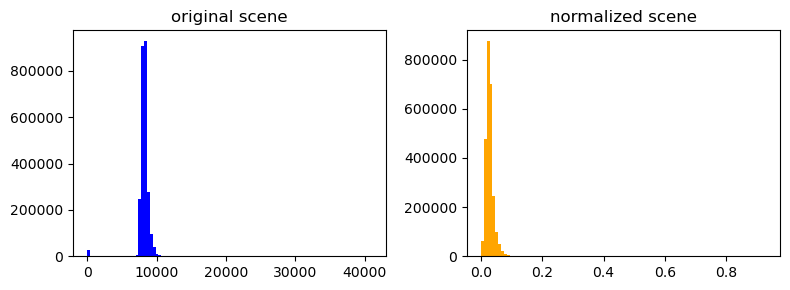

In [12]:
## check normalization
id = 90
path_scene = paths_scene[id]
print(path_scene)
path_scene_nor = path_scene.replace('scene_ori/', 'scene_nor/')
scene_rio, scene_nor_rio = rio.open(path_scene), rio.open(path_scene_nor)
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].hist(scene_rio.read(1).flatten(), bins=100, color='blue');
ax[0].set_title('original scene');
ax[1].hist(scene_nor_rio.read(1).flatten(), bins=100, color='orange');
ax[1].set_title('normalized scene');
plt.tight_layout() 


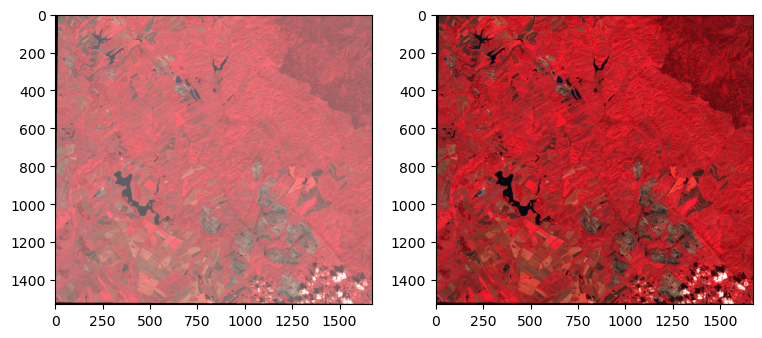

In [13]:
imsShow([scene_rio.read().transpose(1, 2, 0), 
                scene_nor_rio.read().transpose(1, 2, 0)], 
                clip_list=[1, 1], 
                color_bands_list=[[3, 2, 1], [3, 2, 1]],
                figsize=(9, 5));
